In [1]:
# Portfolio Optimization using Modern Portfolio Theory

# ├── Step 1: Import Libraries
# ├── Step 2: User Inputs
# ├── Step 3: Download Historical Data
# ├── Step 4: Data Validation
# ├── Step 5: Calculate Returns
# ├── Step 6: Risk & Return Analysis
# ├── Step 7: Monte Carlo Simulation
# ├── Step 8: Portfolio Optimization
# ├── Step 9: Efficient Frontier
# ├── Step 10: Risk Metrics
# └── Step 11: Interactive Dashboard

In [2]:
import pandas as pd
import yfinance as yf
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [3]:
stocks = ["HDFCBANK.NS" , "SBIN.NS" , "ICICIBANK.NS" , "KOTAKBANK.NS" , "AXISBANK.NS"]
data = yf.download(stocks, start = "2021-01-01" , end = "2025-12-31")

[*********************100%***********************]  5 of 5 completed


In [4]:
data

Price             Close                                                    \
Ticker      AXISBANK.NS HDFCBANK.NS ICICIBANK.NS KOTAKBANK.NS     SBIN.NS   
Date                                                                        
2021-01-01   621.206238  663.905701   510.191467   397.150787  253.242310   
2021-01-04   622.102478  659.689453   514.253601   391.474518  254.737823   
2021-01-05   661.687195  664.674316   519.621582   390.319366  255.372284   
2021-01-06   651.529663  661.809204   528.761414   392.440430  258.363342   
2021-01-07   668.309570  659.805969   523.345154   388.855469  260.765259   
...                 ...         ...          ...          ...         ...   
2025-12-23  1225.000000  980.384949  1363.000000   432.540009  954.691650   
2025-12-24  1226.300049  980.975220  1359.800049   432.739990  951.793884   
2025-12-26  1228.199951  975.958191  1350.400024   432.839996  949.190735   
2025-12-29  1232.000000  975.564697  1343.300049   431.720001  947.962891   
2025-12-30  1246.000000  974.777771  1342.500000   430.540009  956.214172   

Price              High                                                    \
Ticker      AXISBANK.NS HDFCBANK.NS ICICIBANK.NS KOTAKBANK.NS     SBIN.NS   
Date                                                                        
2021-01-01   622.849401  672.268267   519.379750   399.919220  253.786143   
2021-01-04   630.367954  669.938866   517.445308   399.520919  257.321009   
2021-01-05   665.122862  666.561163   522.233001   391.245490  256.006760   
2021-01-06   664.376050  670.870593   532.533409   394.153275  262.079502   
2021-01-07   673.687142  667.423135   536.208795   395.149152  264.481391   
...                 ...         ...          ...          ...         ...   
2025-12-23  1239.000000  982.647575  1365.000000   434.179993  960.241576   
2025-12-24  1235.400024  983.139437  1368.199951   435.640015  959.996016   
2025-12-26  1229.900024  980.975248  1362.000000   434.720001  953.807529   
2025-12-29  1233.900024  981.171968  1355.699951   436.359985  951.744759   
2025-12-30  1252.099976  978.811039  1347.099976   433.000000  958.915481   

Price       ...         Open                                        \
Ticker      ...  AXISBANK.NS HDFCBANK.NS ICICIBANK.NS KOTAKBANK.NS   
Date        ...                                                      
2021-01-01  ...   617.671011  670.870619   517.977316   397.718423   
2021-01-04  ...   625.189564  669.938866   514.833890   399.132527   
2021-01-05  ...   615.430324  661.180199   509.369416   390.269556   
2021-01-06  ...   659.247439  668.541181   521.072261   393.137530   
2021-01-07  ...   656.259906  667.376558   534.032623   395.149152   
...         ...          ...         ...          ...          ...   
2025-12-23  ...  1239.000000  974.384222  1361.099976   430.500000   
2025-12-24  ...  1230.000000  976.843543  1363.800049   433.600006   
2025-12-26  ...  1225.000000  979.794761  1356.500000   432.399994   
2025-12-29  ...  1228.199951  976.941883  1352.099976   434.119995   
2025-12-30  ...  1233.000000  974.089148  1343.300049   431.940002   

Price                       Volume                                        \
Ticker         SBIN.NS AXISBANK.NS HDFCBANK.NS ICICIBANK.NS KOTAKBANK.NS   
Date                                                                       
2021-01-01  249.163604     6047062     8810938     13592625      5530495   
2021-01-04  255.462943    14068156    15740192     16549750     15707145   
2021-01-05  252.018671    37973963    14386824     23311516     16316150   
2021-01-06  256.505276    20829645    22134050     28178838     17262575   
2021-01-07  261.943540    17887570    19894842     21138034     17096585   
...                ...         ...         ...          ...          ...   
2025-12-23  959.013708     2920318    17927849      9105467      8070815   
2025-12-24  955.968634     3155506    13699996      8955140      7791790   
2025-12-26  951.793838   

In [5]:
print(data.columns)

MultiIndex([( 'Close',  'AXISBANK.NS'),
            ( 'Close',  'HDFCBANK.NS'),
            ( 'Close', 'ICICIBANK.NS'),
            ( 'Close', 'KOTAKBANK.NS'),
            ( 'Close',      'SBIN.NS'),
            (  'High',  'AXISBANK.NS'),
            (  'High',  'HDFCBANK.NS'),
            (  'High', 'ICICIBANK.NS'),
            (  'High', 'KOTAKBANK.NS'),
            (  'High',      'SBIN.NS'),
            (   'Low',  'AXISBANK.NS'),
            (   'Low',  'HDFCBANK.NS'),
            (   'Low', 'ICICIBANK.NS'),
            (   'Low', 'KOTAKBANK.NS'),
            (   'Low',      'SBIN.NS'),
            (  'Open',  'AXISBANK.NS'),
            (  'Open',  'HDFCBANK.NS'),
            (  'Open', 'ICICIBANK.NS'),
            (  'Open', 'KOTAKBANK.NS'),
            (  'Open',      'SBIN.NS'),
            ('Volume',  'AXISBANK.NS'),
            ('Volume',  'HDFCBANK.NS'),
            ('Volume', 'ICICIBANK.NS'),
            ('Volume', 'KOTAKBANK.NS'),
            ('Volume',      'SBIN.NS')],

In [6]:
prices = data["Close"]

In [7]:
print(prices.head())

Ticker      AXISBANK.NS  HDFCBANK.NS  ICICIBANK.NS  KOTAKBANK.NS     SBIN.NS
Date                                                                        
2021-01-01   621.206238   663.905701    510.191467    397.150787  253.242310
2021-01-04   622.102478   659.689453    514.253601    391.474518  254.737823
2021-01-05   661.687195   664.674316    519.621582    390.319366  255.372284
2021-01-06   651.529663   661.809204    528.761414    392.440430  258.363342
2021-01-07   668.309570   659.805969    523.345154    388.855469  260.765259


In [8]:
print(prices.isnull().sum())

Ticker
AXISBANK.NS     0
HDFCBANK.NS     0
ICICIBANK.NS    0
KOTAKBANK.NS    0
SBIN.NS         0
dtype: int64


In [9]:
prices = prices.dropna()

In [10]:
prices

Ticker,AXISBANK.NS,HDFCBANK.NS,ICICIBANK.NS,KOTAKBANK.NS,SBIN.NS
Date,,,,,
2021-01-01,621.206238,663.905701,510.191467,397.150787,253.242310
2021-01-04,622.102478,659.689453,514.253601,391.474518,254.737823
2021-01-05,661.687195,664.674316,519.621582,390.319366,255.372284
2021-01-06,651.529663,661.809204,528.761414,392.440430,258.363342
2021-01-07,668.309570,659.805969,523.345154,388.855469,260.765259
...,...,...,...,...,...
2025-12-23,1225.000000,980.384949,1363.000000,432.540009,954.691650
2025-12-24,1226.300049,980.975220,1359.800049,432.739990,951.793884
2025-12-26,1228.199951,975.958191,1350.400024,432.839996,949.190735


In [11]:
returns = prices.pct_change()

In [12]:
print(returns.head())

Ticker      AXISBANK.NS  HDFCBANK.NS  ICICIBANK.NS  KOTAKBANK.NS   SBIN.NS
Date                                                                      
2021-01-01          NaN          NaN           NaN           NaN       NaN
2021-01-04     0.001443    -0.006351      0.007962     -0.014292  0.005905
2021-01-05     0.063631     0.007556      0.010438     -0.002951  0.002491
2021-01-06    -0.015351    -0.004311      0.017589      0.005434  0.011713
2021-01-07     0.025755    -0.003027     -0.010243     -0.009135  0.009297


In [13]:
returns = returns.dropna()

In [14]:
print(returns.head())

Ticker      AXISBANK.NS  HDFCBANK.NS  ICICIBANK.NS  KOTAKBANK.NS   SBIN.NS
Date                                                                      
2021-01-04     0.001443    -0.006351      0.007962     -0.014292  0.005905
2021-01-05     0.063631     0.007556      0.010438     -0.002951  0.002491
2021-01-06    -0.015351    -0.004311      0.017589      0.005434  0.011713
2021-01-07     0.025755    -0.003027     -0.010243     -0.009135  0.009297
2021-01-08     0.002384     0.010874      0.001756      0.009373 -0.005909


In [15]:
print(returns.mean())

Ticker
AXISBANK.NS     0.000690
HDFCBANK.NS     0.000401
ICICIBANK.NS    0.000880
KOTAKBANK.NS    0.000173
SBIN.NS         0.001214
dtype: float64


In [16]:
print(returns.std())

Ticker
AXISBANK.NS     0.015843
HDFCBANK.NS     0.013383
ICICIBANK.NS    0.013911
KOTAKBANK.NS    0.014645
SBIN.NS         0.016546
dtype: float64


In [17]:
annual_return = returns.mean() * 252

In [18]:
print(annual_return)

Ticker
AXISBANK.NS     0.173755
HDFCBANK.NS     0.100986
ICICIBANK.NS    0.221845
KOTAKBANK.NS    0.043544
SBIN.NS         0.305945
dtype: float64


In [19]:
annual_volatility = returns.std() * (252 **0.5)

In [20]:
print(annual_volatility)

Ticker
AXISBANK.NS     0.251497
HDFCBANK.NS     0.212442
ICICIBANK.NS    0.220831
KOTAKBANK.NS    0.232482
SBIN.NS         0.262665
dtype: float64


In [21]:
summary = pd.DataFrame({
    "Annual Return": annual_return,
    "Annual Volatility": annual_volatility
})

In [22]:
print(summary)

              Annual Return  Annual Volatility
Ticker                                        
AXISBANK.NS        0.173755           0.251497
HDFCBANK.NS        0.100986           0.212442
ICICIBANK.NS       0.221845           0.220831
KOTAKBANK.NS       0.043544           0.232482
SBIN.NS            0.305945           0.262665


In [23]:
summary["Sharpe_ratio"] = (
    summary["Annual Return"] / summary["Annual Volatility"]
)

In [24]:
print(summary)

              Annual Return  Annual Volatility  Sharpe_ratio
Ticker                                                      
AXISBANK.NS        0.173755           0.251497      0.690881
HDFCBANK.NS        0.100986           0.212442      0.475359
ICICIBANK.NS       0.221845           0.220831      1.004590
KOTAKBANK.NS       0.043544           0.232482      0.187300
SBIN.NS            0.305945           0.262665      1.164773


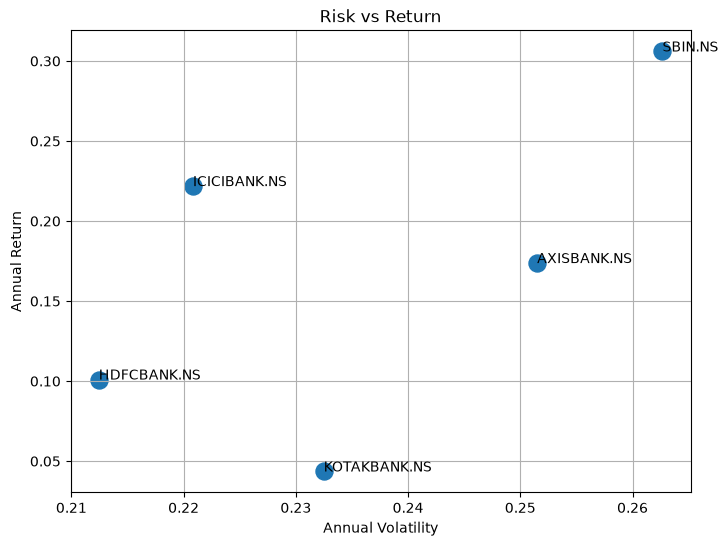

In [25]:
plt.figure(figsize=(8,6))

plt.scatter(
    annual_volatility,
    annual_return,
    s = 150
)

for stock in annual_return.index:
    plt.annotate(stock,
                 (
                     annual_volatility[stock],
                     annual_return[stock]
                 )
                )
    
plt.xlabel("Annual Volatility")
plt.ylabel("Annual Return")
plt.title("Risk vs Return")
plt.grid(True)

plt.show()

In [26]:
print(summary)

              Annual Return  Annual Volatility  Sharpe_ratio
Ticker                                                      
AXISBANK.NS        0.173755           0.251497      0.690881
HDFCBANK.NS        0.100986           0.212442      0.475359
ICICIBANK.NS       0.221845           0.220831      1.004590
KOTAKBANK.NS       0.043544           0.232482      0.187300
SBIN.NS            0.305945           0.262665      1.164773


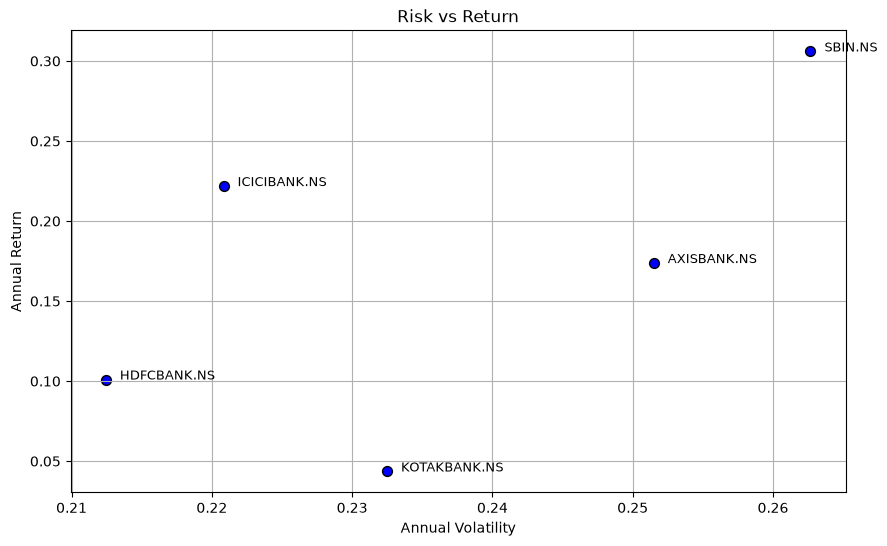

In [27]:
plt.figure(figsize=(10, 6))
plt.scatter(summary['Annual Volatility'], summary['Annual Return'], color='blue', edgecolors='black', s=50)

for stock in summary.index:
    plt.text(summary.loc[stock, 'Annual Volatility'] + 0.001, summary.loc[stock, 'Annual Return'], stock, fontsize=9)

plt.title('Risk vs Return')
plt.xlabel('Annual Volatility')
plt.ylabel('Annual Return')
plt.grid(True)
plt.show()

Text(0, 0.5, 'Annual Return (%)')

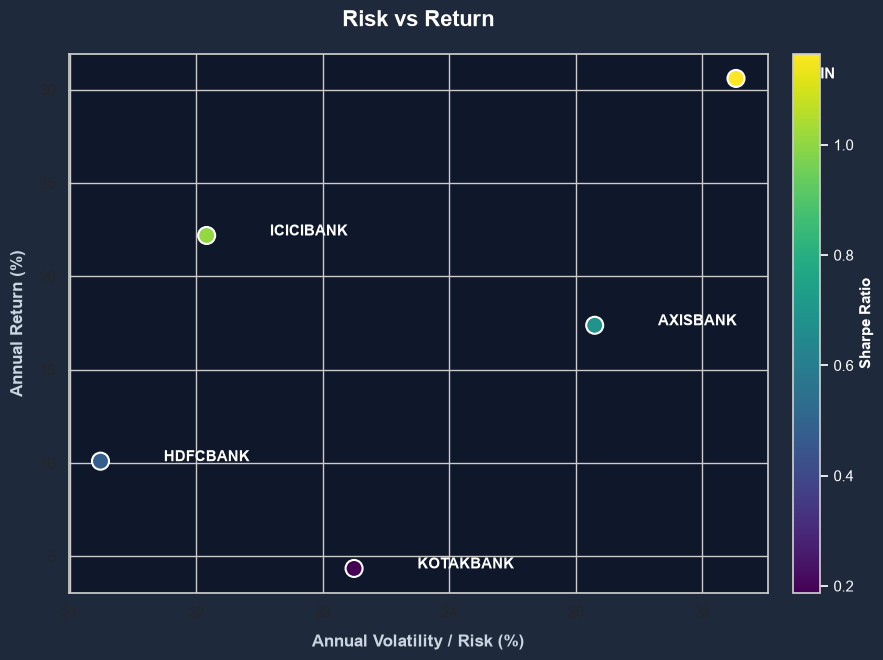

In [28]:
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(11,7))
fig.patch.set_facecolor("#1e293b")
ax.set_facecolor("#0f172a")

scatter = ax.scatter(
    summary["Annual Volatility"] * 100,
    summary["Annual Return"] * 100,
    c = summary["Sharpe_ratio"],
    cmap = "viridis",
    s = 150,
    edgecolors = "white",
    linewidths = 1.5,
    zorder = 3
)

cbar = plt.colorbar(scatter, pad = 0.03)
cbar.set_label("Sharpe Ratio" , color = "white" , fontsize = 11, weight = "bold")
cbar.ax.yaxis.set_tick_params(color='white', labelcolor='white')
for stock in summary.index:
    clean_name = stock.replace('.NS', '')
    ax.text(
        (summary.loc[stock, 'Annual Volatility'] * 100) + 0.5,
        (summary.loc[stock, 'Annual Return'] * 100), 
        clean_name, 
        fontsize=11, 
        weight='bold', 
        color='white'
    )
    
ax.set_title('Risk vs Return', fontsize=16, weight='bold', color='white', pad=20)
ax.set_xlabel('Annual Volatility / Risk (%)', fontsize=12, color='#cbd5e1', weight='bold', labelpad=10)
ax.set_ylabel('Annual Return (%)', fontsize=12, color='#cbd5e1', weight='bold', labelpad=10)

In [29]:
cov_matrix = returns.cov() * 252
print(cov_matrix)

Ticker        AXISBANK.NS  HDFCBANK.NS  ICICIBANK.NS  KOTAKBANK.NS   SBIN.NS
Ticker                                                                      
AXISBANK.NS      0.063251     0.023373      0.034019      0.023629  0.036156
HDFCBANK.NS      0.023373     0.045132      0.024971      0.024625  0.023656
ICICIBANK.NS     0.034019     0.024971      0.048767      0.024372  0.032431
KOTAKBANK.NS     0.023629     0.024625      0.024372      0.054048  0.024784
SBIN.NS          0.036156     0.023656      0.032431      0.024784  0.068993


In [30]:
weights = np.random.random(len(stocks))
weights = weights / np.sum(weights)

print(weights)
print(np.sum(weights))

[0.02291386 0.11194951 0.34154474 0.33661762 0.18697428]
0.9999999999999999


In [31]:
portfolio_return = np.sum(weights * annual_return)

In [32]:
print(portfolio_return)

0.16291828923700916


In [33]:
portfolio_volatility = np.sqrt(
    np.dot(
        weights.T,
        np.dot(cov_matrix, weights)
    )
)

In [34]:
print(portfolio_volatility)

0.18377251248817247


In [35]:
risk_free_rate = 0.06
portfolio_sharpe = (portfolio_return - risk_free_rate) / portfolio_volatility

In [36]:
print(portfolio_sharpe)

0.5600309199866489


In [37]:
num_assets = len(stocks)
weights = np.random.random(num_assets)
weights = weights / np.sum(weights)
print("Weights:")
print(weights)
print("\nTotal Weight:")
print(np.sum(weights))

Weights:
[0.26166385 0.341142   0.28009674 0.09623946 0.02085796]

Total Weight:
0.9999999999999999


In [38]:
annual_return

Ticker
AXISBANK.NS     0.173755
HDFCBANK.NS     0.100986
ICICIBANK.NS    0.221845
KOTAKBANK.NS    0.043544
SBIN.NS         0.305945
dtype: float64

In [39]:
portfolio_return = np.sum(weights * annual_return)
print("Expected Portfolio Return:")
print(portfolio_return)

Expected Portfolio Return:
0.15262617135615492


In [40]:
portfolio_volatility = np.sqrt(
    np.dot(
        weights.T,
        np.dot(cov_matrix, weights)
    )
)
print("Expected Portfolio Volatility")
print(portfolio_volatility)

Expected Portfolio Volatility
0.1822135723662173


In [41]:
portfolio_sharpe = (portfolio_return - risk_free_rate) / portfolio_volatility
print("Portfolio Sharpe:")
print(portfolio_sharpe)

Portfolio Sharpe:
0.5083384851815131


In [42]:
portfolio_returns = []
portfolio_weights = []
portfolio_volatilities = []
portfolio_sharpes = []

In [43]:
portfolio_returns = []
portfolio_weights = []
portfolio_volatilities = []
portfolio_sharpes = []

num_portfolios = 10000

for i in range(num_portfolios):
    
    # Generate random weights
    weights = np.random.random(num_assets)
    weights = weights / np.sum(weights)
    
    # Portfolio Returns
    portfolio_return = np.sum(weights * annual_return)
    
    # Portfolio Volatility
    portfolio_volatility = np.sqrt(
        np.dot(weights.T, np.dot(cov_matrix, weights))
    )
    
    # Portfolio Sharpe   
    portfolio_sharpe = (portfolio_return - risk_free_rate) / portfolio_volatility
    
    # Storing
    portfolio_sharpes.append(portfolio_sharpe)
    portfolio_weights.append(weights)
    portfolio_returns.append(portfolio_return)
    portfolio_volatilities.append(portfolio_volatility)

In [44]:
portfolio_df = pd.DataFrame({
    'Return': portfolio_returns,
    'Volatility': portfolio_volatilities,
    'Sharpe Ratio': portfolio_sharpes
})
portfolio_df.head()

,Return,Volatility,Sharpe Ratio
0,0.137790,0.178080,0.436826
1,0.171146,0.182223,0.609947
2,0.215630,0.191471,0.812816
3,0.128118,0.186378,0.365484
4,0.153088,0.183662,0.506846


In [45]:
portfolio_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Return        10000 non-null  float64
 1   Volatility    10000 non-null  float64
 2   Sharpe Ratio  10000 non-null  float64
dtypes: float64(3)
memory usage: 234.5 KB


In [46]:
portfolio_df.describe()

,Return,Volatility,Sharpe Ratio
count,10000.000000,10000.000000,10000.000000
mean,0.169287,0.186541,0.583509
std,0.025906,0.006370,0.125064
min,0.083260,0.177544,0.120844
25%,0.152091,0.181861,0.504267
50%,0.169263,0.185163,0.589949
75%,0.185848,0.189613,0.669665
max,0.280370,0.236690,0.954722


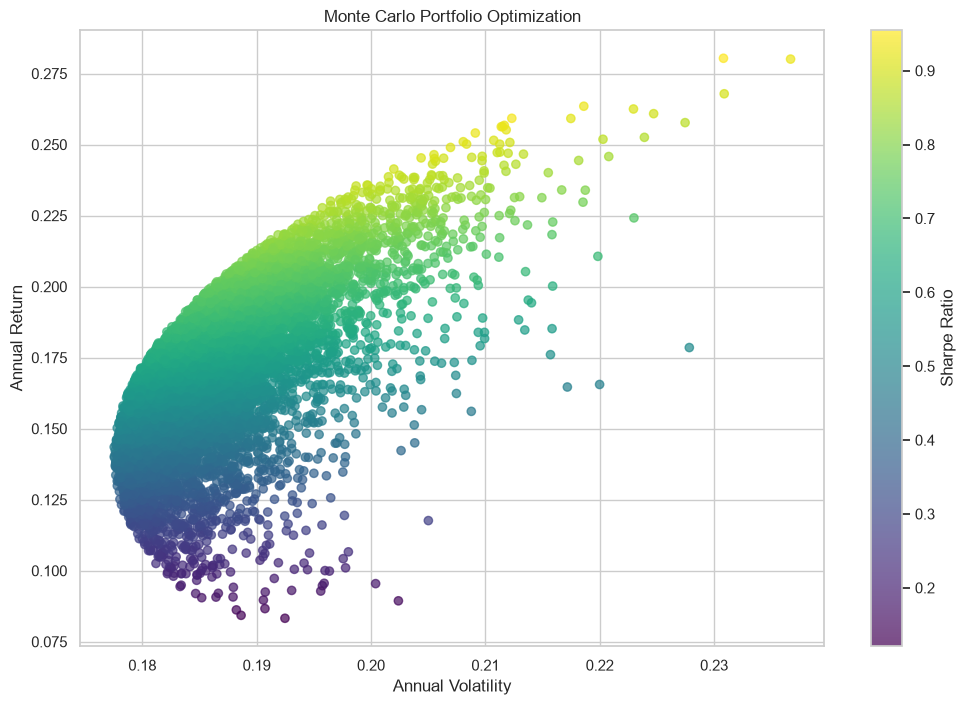

In [47]:
plt.figure(figsize=(12,8))

scatter = plt.scatter(
    portfolio_df['Volatility'],
    portfolio_df["Return"],
    c = portfolio_df['Sharpe Ratio'],
    cmap= 'viridis',
    alpha = 0.7
)

plt.colorbar(scatter, label='Sharpe Ratio')

plt.xlabel('Annual Volatility')
plt.ylabel('Annual Return')

plt.title("Monte Carlo Portfolio Optimization")
plt.grid(True)

plt.show()

In [48]:
# Highest Sharpe Ratio
max_sharpe_idx = portfolio_df['Sharpe Ratio'].idxmax()
# info of the portfolio
max_sharpe_portfolio = portfolio_df.loc[max_sharpe_idx]

print(max_sharpe_portfolio)

Return          0.280370
Volatility      0.230821
Sharpe Ratio    0.954722
Name: 8374, dtype: float64


In [49]:
min_sharpe_idx = portfolio_df['Sharpe Ratio'].idxmin()
min_sharpe_portfolio = portfolio_df.loc[min_sharpe_idx]

print(min_sharpe_portfolio)

Return          0.083260
Volatility      0.192475
Sharpe Ratio    0.120844
Name: 2767, dtype: float64


In [50]:
# Portfolio with lowest volatility
min_volatility_idx = portfolio_df['Volatility'].idxmin()
# Info of the portfolio
min_volatility_portfolio = portfolio_df.loc[min_volatility_idx]

print(min_volatility_portfolio)

Return          0.143537
Volatility      0.177544
Sharpe Ratio    0.470514
Name: 9368, dtype: float64


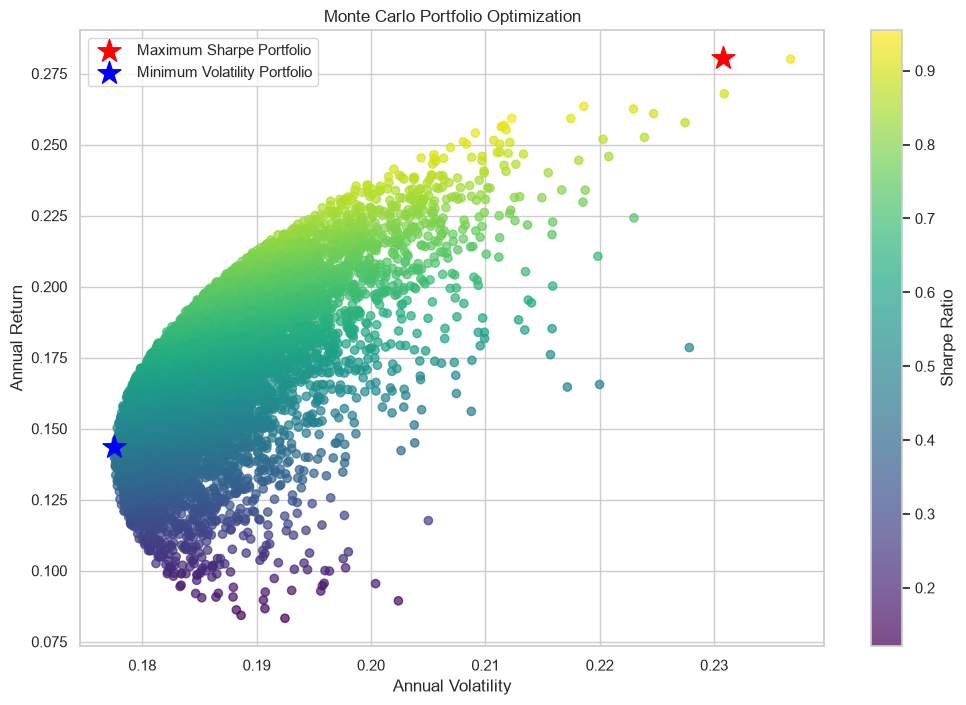

In [51]:
plt.figure(figsize= (12,8))

scatter = plt.scatter(
    portfolio_df['Volatility'],
    portfolio_df['Return'],
    c = portfolio_df['Sharpe Ratio'],
    cmap = 'viridis',
    alpha = 0.7
)

plt.colorbar(scatter, label = 'Sharpe Ratio')

# Maximum Sharpe Portfolio
plt.scatter(
    max_sharpe_portfolio['Volatility'],
    max_sharpe_portfolio['Return'],
    color = 'red',
    marker = '*',
    s = 300,
    label = 'Maximum Sharpe Portfolio'
)

# Minimum Volatility Portfolio
plt.scatter(
    min_volatility_portfolio['Volatility'],
    min_volatility_portfolio['Return'],
    color = 'blue',
    marker = '*',
    s = 300,
    label = 'Minimum Volatility Portfolio'
)

# Labeling
plt.xlabel('Annual Volatility')
plt.ylabel('Annual Return')
plt.title('Monte Carlo Portfolio Optimization')

plt.legend()
plt.grid(True)

plt.show()

In [52]:
optimal_weights = portfolio_weights[max_sharpe_idx]
print(optimal_weights)

[0.00681831 0.0330101  0.2060563  0.0022058  0.75190949]


In [53]:
weights_df = pd.DataFrame({
    'Stock': stocks,
    'Weight': optimal_weights
})
weights_df

,Stock,Weight
0,HDFCBANK.NS,0.006818
1,SBIN.NS,0.033010
2,ICICIBANK.NS,0.206056
3,KOTAKBANK.NS,0.002206
4,AXISBANK.NS,0.751909


In [54]:
weights_df['Weight (%)'] = weights_df['Weight'] * 100
weights_df[['Stock' , 'Weight (%)']]
weights_df = weights_df.sort_values(
    by = 'Weight (%)',
    ascending = False
)

weights_df

,Stock,Weight,Weight (%)
4,AXISBANK.NS,0.751909,75.190949
2,ICICIBANK.NS,0.206056,20.605630
1,SBIN.NS,0.033010,3.301010
0,HDFCBANK.NS,0.006818,0.681831
3,KOTAKBANK.NS,0.002206,0.220580


In [55]:
summary_df = pd.DataFrame({
    'Portfolio': ['Maximum Sharpe' , 'Minimum Volatility'],
    'Annual Return' : [
        max_sharpe_portfolio['Return'],
        min_volatility_portfolio['Return']
    ],
    'Annual Volatility': [
        max_sharpe_portfolio['Volatility'],
        min_volatility_portfolio['Volatility']
    ],
    'Sharpe Ratio': [
        max_sharpe_portfolio['Sharpe Ratio'],
        min_volatility_portfolio['Sharpe Ratio']
    ]
})

summary_df

,Portfolio,Annual Return,Annual Volatility,Sharpe Ratio
0,Maximum Sharpe,0.280370,0.230821,0.954722
1,Minimum Volatility,0.143537,0.177544,0.470514


In [56]:
summary_df['Annual Return'] = summary_df['Annual Return'] * 100
summary_df['Annual Volatility'] = summary_df['Annual Volatility'] * 100
summary_df = summary_df.round(2)

In [57]:
summary_df

,Portfolio,Annual Return,Annual Volatility,Sharpe Ratio
0,Maximum Sharpe,28.04,23.08,0.95
1,Minimum Volatility,14.35,17.75,0.47


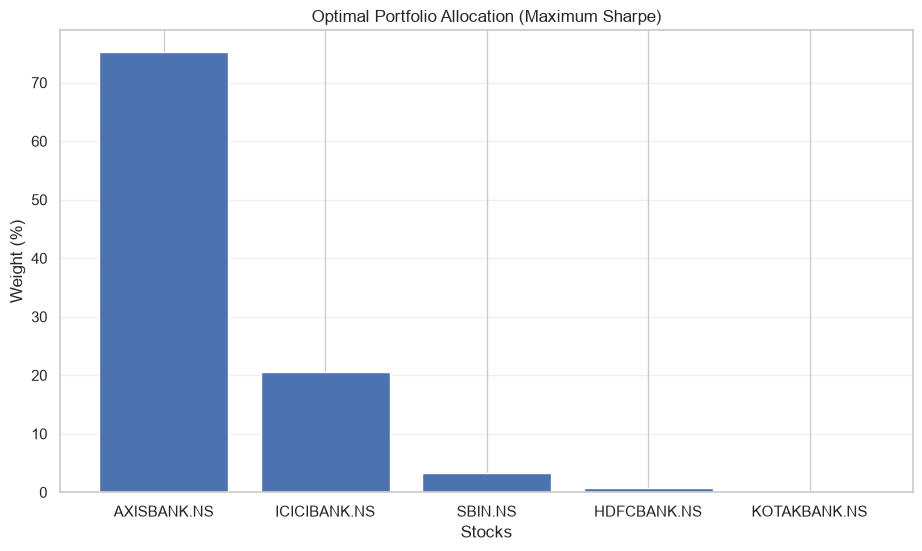

In [62]:
plt.figure(figsize=(11,6))

plt.bar(
    weights_df['Stock'],
    weights_df['Weight (%)']
)
plt.title('Optimal Portfolio Allocation (Maximum Sharpe)')
plt.xlabel('Stocks')
plt.ylabel('Weight (%)')

plt.grid(axis = 'y' , alpha = 0.3)
plt.tight_layout

plt.show()

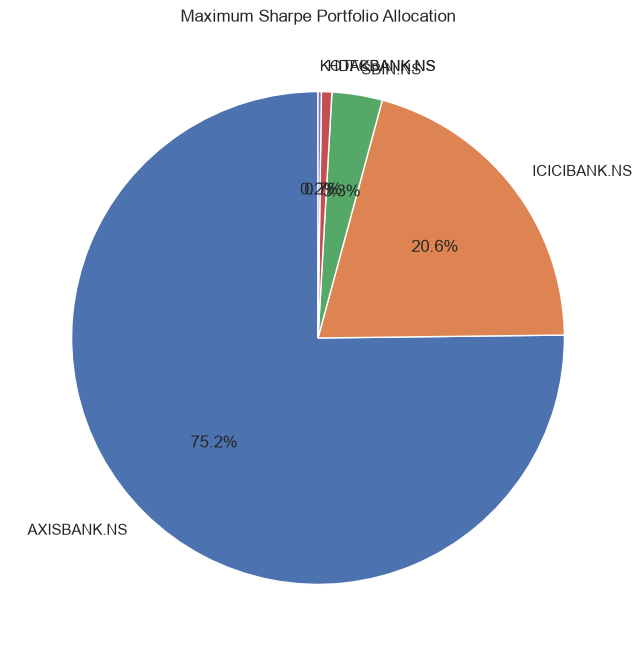

In [72]:
plt.figure(figsize=(8,8))

plt.pie(
    weights_df["Weight (%)"],
    labels = weights_df['Stock'],
    autopct = '%1.1f%%' ,
    startangle= 90
)
plt.title('Maximum Sharpe Portfolio Allocation')

plt.show()

In [73]:
correlation_matrix = daily_returns.corr()
correlation_matrix

NameError: name 'daily_returns' is not defined